# 06 Training-set selection and fine-tuning strategies

Self-filling across the 8 targets. Two parts.

**Part I, standard selection (runs for every target with `ft_inputs_full/train_ids_top{N}.txt`, scoring results where fully scored).** The paper's head fine-tuning trains on the top-N compounds of the Boltz-2 No-FT ranking (N = 40, 100, 300). What do those training sets contain (active fraction, diversity of the actives), are they the same across seeds, and how does N change AP?

**Part II, strategy variants (runs for every target that has `results/analysis/<target>/variants_*.csv`).** Balanced selection, hard negatives, other recipes and budgets up to 1000, on a held-out evaluation set (compounds ranked below 1000 by No-FT). Targets without variant arms print `no variant arms for this target yet`.

The paper has no strategy-variant experiment, so paper values appear only where it reports them (No-FT and head-FT AP per target and N, `trainer_control.csv`).

In [1]:

import sys; sys.path.insert(0, "/global/scratch/users/sergiomar10/boltzaff/pipeline_local")
from bft_training import *
import matplotlib.pyplot as plt
from IPython.display import display
style()
COL = {"top": OUR, "balanced": "#1baf7a", "actdiv": "#9467bd", "random": "#8c564b", "diverse": "#17becf", "stratified": "#e377c2", "hardneg": "#d62728"}
NCOL = {40: "#9ecae1", 100: "#4a90d9", 300: "#1f4e99"}
NAMES = {t: SHORT[t] for t in TARGETS}


## 0. What is available per target

In [2]:
ST = status()
VAR = {t: variants(t) for t in TARGETS}
SETS = {t: std_sets(t) for t in TARGETS}
AP = {}
for t in TARGETS:
    try: AP[t] = ap_by_arm(t)
    except Exception as e: AP[t] = None; print(f"{SHORT[t]}: AP error {e!r}")
rows = []
for t in TARGETS:
    v = VAR[t]
    rows.append(dict(target=SHORT[t], train_sets=SETS[t] is not None, fully_scored=AP[t] is not None, arms_scored=ST.loc[SHORT[t], "arms_scored"],
                     variant_arms=(0 if v is None else len(v[0])), variant_conditions=(0 if v is None else len(v[1]))))
AV = pd.DataFrame(rows).set_index("target"); display(AV)
for t in TARGETS:
    if SETS[t] is None: print(f"pending: {SHORT[t]} - no ft_inputs_full/train_ids_top{{N}}.txt yet")
    elif AP[t] is None: print(f"pending (AP panels only): {SHORT[t]} - training sets exist but {ST.loc[SHORT[t], 'arms_scored']} arms scored")
    if VAR[t] is None: print(f"no variant arms for this target yet: {SHORT[t]}")
T_SET = [t for t in TARGETS if SETS[t] is not None]; T_AP = [t for t in TARGETS if AP[t] is not None]; T_VAR = [t for t in TARGETS if VAR[t] is not None]
print(f"\nPart I composition: {[SHORT[t] for t in T_SET]}; Part I AP: {[SHORT[t] for t in T_AP]}; Part II variants: {[SHORT[t] for t in T_VAR]}")

,train_sets,fully_scored,arms_scored,variant_arms,variant_conditions
target,,,,,
588689,True,True,16/16,70,14
504329,True,True,16/16,0,0
743445,True,True,16/16,0,0
485317,True,True,16/16,0,0
2097,False,False,0/16,0,0
493091,True,False,0/16,0,0
2650,False,False,0/16,0,0
588549,False,False,0/16,0,0


no variant arms for this target yet: 504329
no variant arms for this target yet: 743445
no variant arms for this target yet: 485317
pending: 2097 - no ft_inputs_full/train_ids_top{N}.txt yet
no variant arms for this target yet: 2097
pending (AP panels only): 493091 - training sets exist but 0/16 arms scored
no variant arms for this target yet: 493091
pending: 2650 - no ft_inputs_full/train_ids_top{N}.txt yet
no variant arms for this target yet: 2650
pending: 588549 - no ft_inputs_full/train_ids_top{N}.txt yet
no variant arms for this target yet: 588549

Part I composition: ['588689', '504329', '743445', '485317', '493091']; Part I AP: ['588689', '504329', '743445', '485317']; Part II variants: ['588689']


# Part I. The standard top-N training sets

## 1. What the training sets contain
The top-N selection takes the N best-ranked compounds under the No-FT model. `active_frac` is the share of true actives in the training set; `pool_rate` is the active rate of the whole library (what random selection would give); `enrichment` = active_frac / pool_rate. The paper trains the head on these sets with 20 extra validation compounds (the last 20 of the ranking).

,active_frac N=40,active_frac N=100,active_frac N=300,n_active N=40,n_active N=100,n_active N=300,pool_rate
target,,,,,,,
485317,0.025,0.09,0.077,1,9,23,0.019529
493091,0.200,0.16,0.143,8,16,43,0.015645
504329,0.100,0.11,0.093,4,11,28,0.009325
588689,0.400,0.32,0.300,16,32,90,0.009723
743445,0.000,0.05,0.033,0,5,10,0.002880


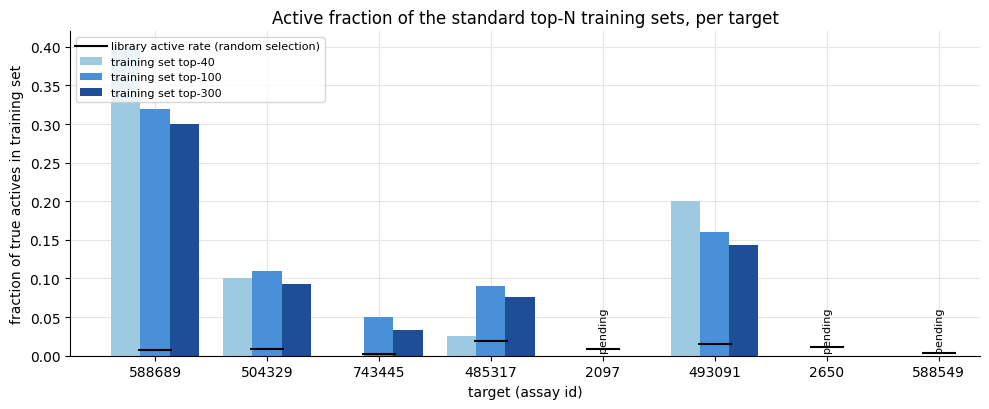

Training sets are 0% to 40% active across targets and N, against library rates of 0.27% to 1.92%.


In [3]:
rows = []
for t in T_SET:
    m = ml(t); pool = m.is_binder.mean()
    for N, d in SETS[t].items():
        rows.append(dict(target=SHORT[t], N=N, n_active=int(d.is_binder.sum()), active_frac=d.is_binder.mean(), pool_rate=pool, enrichment=d.is_binder.mean() / pool,
                         mean_noft_score=d.affinity_probability_binary.mean(), pool_n=len(m)))
COMP = pd.DataFrame(rows)
display(COMP.pivot(index="target", columns="N", values="active_frac").round(3).rename(columns=lambda N: f"active_frac N={N}").join(
        COMP.pivot(index="target", columns="N", values="n_active").rename(columns=lambda N: f"n_active N={N}")).join(COMP.groupby("target").pool_rate.first()))
fig, ax = plt.subplots(figsize=(10, 4.2)); x = np.arange(len(TARGETS)); w = 0.26
for i, N in enumerate(BUDGETS):
    y = [COMP[(COMP.target == SHORT[t]) & (COMP.N == N)].active_frac.squeeze() if t in T_SET else np.nan for t in TARGETS]
    ax.bar(x + (i - 1) * w, y, w, color=NCOL[N], label=f"training set top-{N}")
ax.scatter(x, [RATE[t] for t in TARGETS], marker="_", s=600, color="black", zorder=5, label="library active rate (random selection)")
for j, t in enumerate(TARGETS):
    if t not in T_SET: ax.text(j, 0.005, "pending", rotation=90, ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([SHORT[t] for t in TARGETS]); ax.set_xlabel("target (assay id)"); ax.set_ylabel("fraction of true actives in training set")
ax.set_title("Active fraction of the standard top-N training sets, per target"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()
if len(COMP): print("Training sets are", f"{COMP.active_frac.min():.0%} to {COMP.active_frac.max():.0%}", "active across targets and N, against library rates of", f"{min(RATE[t] for t in T_SET):.2%} to {max(RATE[t] for t in T_SET):.2%}.")

## 2. Are the training sets the same across seeds, and nested across N?
Selection is written once per N (`train_ids_top{N}.txt`, no seed in the name), so the 5 seeds share one training set and the validation compounds; seeds only change the training run. The check below reads the validation-id files of each seed where present and the nesting of the sets.

In [4]:
rows = []
for t in T_SET:
    ids = {N: train_ids(t, N) for N in BUDGETS}; r = dict(target=SHORT[t])
    r["top40 in top100"] = len(set(ids[40]) & set(ids[100])) / len(ids[40]); r["top100 in top300"] = len(set(ids[100]) & set(ids[300])) / len(ids[100])
    vs = {}
    for N in BUDGETS:
        for p in sorted((RUNS / t / "headft_full").glob(f"work_top{N}_seed*.val_ids.txt")):
            vs.setdefault(N, []).append(tuple(l.strip() for l in open(p) if l.strip()))
    r["val sets found"] = sum(len(v) for v in vs.values()); r["val ids identical across seeds"] = (all(len(set(v)) == 1 for v in vs.values()) if vs else np.nan)
    r["val n"] = len(next(iter(vs.values()))[0]) if vs else np.nan
    rows.append(r)
if rows: display(pd.DataFrame(rows).set_index("target"))
else: print("no targets with training sets yet")

,top40 in top100,top100 in top300,val sets found,val ids identical across seeds,val n
target,,,,,
588689,1.0,1.0,15,True,20.0
504329,1.0,1.0,15,True,20.0
743445,1.0,1.0,15,True,20.0
485317,1.0,1.0,15,True,20.0
493091,1.0,1.0,0,NaN,NaN


## 3. Diversity of the training actives
For each target and N: number of actives, distinct Bemis-Murcko scaffolds, and mean pairwise ECFP4 Tanimoto among the training actives. The reference is the same number of actives drawn at random from all library actives (mean of 200 draws); a training set below the reference in scaffold count or above it in similarity is narrower than a random sample of actives. Last column: median over evaluation-set actives of the maximum Tanimoto to the training actives, i.e. how analogue-like the compounds to be found are relative to what was trained on.

n_active  scaffolds  scaffolds_random_ref  mean_pair_tanimoto  \
target N                                                                    
588689 40         16       16.0                15.635               0.102   
       100        32       29.0                30.040               0.128   
       300        90       70.0                77.325               0.131   
504329 40          4        3.0                 3.990               0.370   
       100        11       10.0                10.850               0.174   
       300        28       25.0                27.200               0.158   
743445 40          0        NaN                   NaN                 NaN   
       100         5        5.0                 4.955               0.130   
       300        10        8.0                 9.920               0.187   
485317 40          1        NaN                   NaN                 NaN   
       100         9        9.0                 8.940               0.134   
       300        23       23.0                22.775               0.135   
493091 40          8        7.0                 7.990               0.161   
       100        16       15.0                15.855               0.150   
       300        43       38.0                42.075               0.145   

            pair_tanimoto_random_ref  eval_active_median_max_tanimoto  
target N                                                               
588689 40                      0.123                            0.199  
       100                     0.124                            0.224  
       300                     0.125                            0.278  
504329 40                      0.139                            0.179  
       100                     0.136                            0.208  
       300                     0.136                            0.234  
743445 40                        NaN                              NaN  
       100                     0.118                            0.162  
       300                     0.114                            0.167  
485317 40                        NaN                              NaN  
       100                     0.125                            0.179  
       300                     0.124                            0.213  
493091 40                      0.135                            0.191  
       100                     0.137                            0.212  
       300                     0.138                            0.259

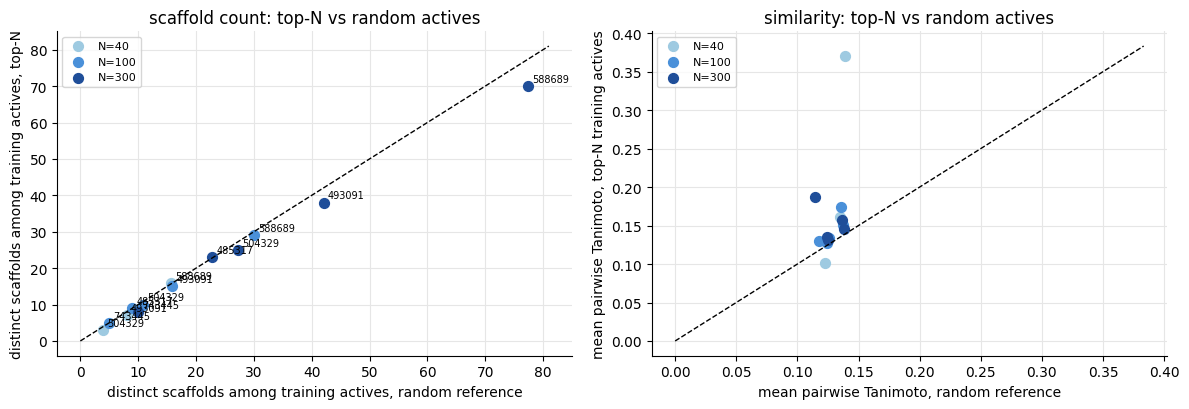

In [5]:
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog("rdApp.*")
def fp(s):
    m = Chem.MolFromSmiles(s) if isinstance(s, str) else None
    return AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) if m else None
def scaf(s):
    try: return MurckoScaffold.MurckoScaffoldSmiles(smiles=s)
    except Exception: return None
def mean_pair(fps):
    if len(fps) < 2: return np.nan
    v = [np.mean(DataStructs.BulkTanimotoSimilarity(f, fps[i + 1:])) * len(fps[i + 1:]) for i, f in enumerate(fps[:-1])]
    return sum(v) / (len(fps) * (len(fps) - 1) / 2)
rng = np.random.default_rng(0); rows = []
for t in T_SET:
    try:
        m = ml(t); act = m[m.is_binder == 1]; afp = {i: fp(s) for i, s in act.smiles.items()}; asc = {i: scaf(s) for i, s in act.smiles.items()}
        for N in BUDGETS:
            ids = [i for i in SETS[t][N].index if SETS[t][N].loc[i, "is_binder"] == 1]; n = len(ids)
            if n < 2: rows.append(dict(target=SHORT[t], N=N, n_active=n)); continue
            tf = [afp[i] for i in ids if afp[i] is not None]
            draws = [rng.choice(act.index.values, n, replace=False) for _ in range(200)]
            ref_sc = np.mean([len({asc[i] for i in d}) for d in draws]); ref_sim = np.mean([mean_pair([afp[i] for i in d if afp[i] is not None]) for d in draws[:50]])
            rest = [i for i in act.index if i not in set(ids)]
            mx = [max(DataStructs.BulkTanimotoSimilarity(afp[i], tf)) for i in rest if afp[i] is not None]
            rows.append(dict(target=SHORT[t], N=N, n_active=n, scaffolds=len({asc[i] for i in ids}), scaffolds_random_ref=ref_sc, mean_pair_tanimoto=mean_pair(tf), pair_tanimoto_random_ref=ref_sim,
                             eval_active_median_max_tanimoto=float(np.median(mx))))
    except Exception as e: print(f"{SHORT[t]}: diversity skipped ({e!r})")
DIV = pd.DataFrame(rows); display(DIV.round(3).set_index(["target", "N"]))
d3 = DIV.dropna(subset=["scaffolds"])
if len(d3):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    for N in BUDGETS:
        s = d3[d3.N == N]; axes[0].scatter(s.scaffolds_random_ref, s.scaffolds, s=50, color=NCOL[N], label=f"N={N}")
        axes[1].scatter(s.pair_tanimoto_random_ref, s.mean_pair_tanimoto, s=50, color=NCOL[N], label=f"N={N}")
        for _, r in s.iterrows(): axes[0].annotate(r.target, (r.scaffolds_random_ref, r.scaffolds), fontsize=7, xytext=(3, 3), textcoords="offset points")
    for ax, (a, b) in zip(axes, [("distinct scaffolds among training actives, random reference", "distinct scaffolds among training actives, top-N"), ("mean pairwise Tanimoto, random reference", "mean pairwise Tanimoto, top-N training actives")]):
        lim = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]; ax.plot(lim, lim, "k--", lw=1); ax.set_xlabel(a); ax.set_ylabel(b); ax.legend(fontsize=8)
    axes[0].set_title("scaffold count: top-N vs random actives"); axes[1].set_title("similarity: top-N vs random actives")
    plt.tight_layout(); plt.show()

## 4. How N changes AP, ours vs paper
AP on the full evaluation set (same set for No-FT and all arms), head-FT as mean and SD over the 5 seeds, next to the paper's single-seed value at the same N (`trainer_control.csv`). The dashed line is the library active rate (AP of a random ranking). Only fully scored targets are drawn; the others show as pending.

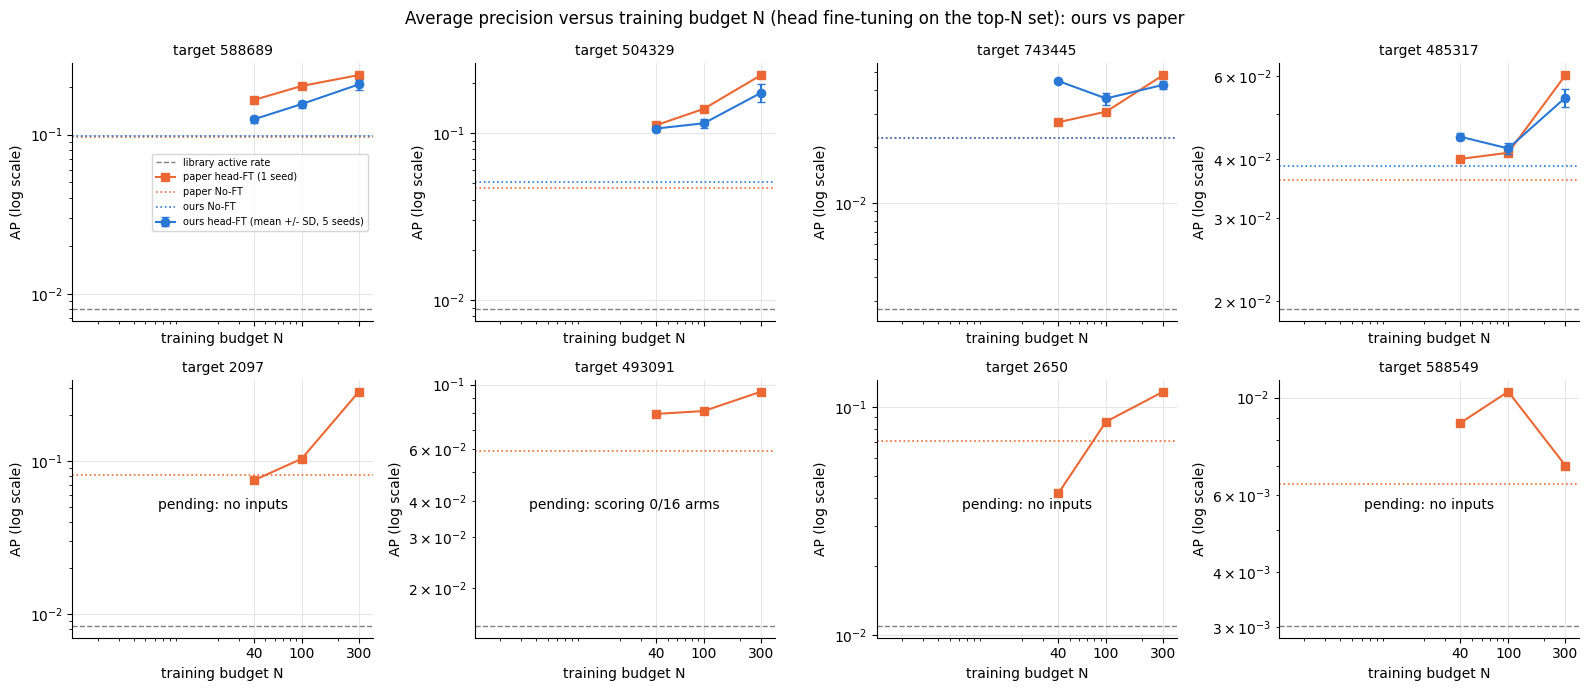

ours_ap  ours_sd  ours_noft  ours_ratio  ours_ratio_sd  paper_ap  \
target N                                                                       
588689 40     0.125    0.006      0.097       1.281          0.063     0.165   
       100    0.155    0.008      0.097       1.597          0.085     0.202   
       300    0.207    0.015      0.097       2.124          0.153     0.237   
504329 40     0.106    0.003      0.051       2.093          0.069     0.111   
       100    0.114    0.008      0.051       2.250          0.153     0.139   
       300    0.174    0.021      0.051       3.424          0.418     0.222   
743445 40     0.045    0.001      0.022       2.012          0.035     0.027   
       100    0.036    0.003      0.022       1.623          0.120     0.031   
       300    0.043    0.002      0.022       1.919          0.091     0.048   
485317 40     0.045    0.001      0.039       1.152          0.020     0.040   
       100    0.042    0.001      0.039       1.087          0.030     0.041   
       300    0.054    0.002      0.039       1.395          0.061     0.060   

            paper_noft  paper_ratio  
target N                             
588689 40        0.096        1.717  
       100       0.096        2.103  
       300       0.096        2.464  
504329 40        0.047        2.388  
       100       0.047        2.992  
       300       0.047        4.764  
743445 40        0.022        1.216  
       100       0.022        1.384  
       300       0.022        2.172  
485317 40        0.036        1.109  
       100       0.036        1.143  
       300       0.036        1.671

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True); rows = []
for ax, t in zip(axes.ravel(), TARGETS):
    ax.set_title(f"target {SHORT[t]}", fontsize=10); ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xticks(BUDGETS); ax.set_xticklabels(BUDGETS)
    ax.axhline(RATE[t], color="gray", ls="--", lw=1, label="library active rate")
    ax.plot(BUDGETS, [PAPER_FT.loc[(t, N), "auprc"] for N in BUDGETS], "s-", color=THEIR, label="paper head-FT (1 seed)")
    ax.axhline(PAPER_BASE.loc[t, "auprc"], color=THEIR, ls=":", lw=1.2, label="paper No-FT")
    d = AP[t]
    if d is None:
        ax.text(0.5, 0.5, "pending: " + ("scoring " + ST.loc[SHORT[t], "arms_scored"] + " arms" if SETS[t] is not None else "no inputs"), transform=ax.transAxes, ha="center"); 
    else:
        g = d[d.N > 0].groupby("N").ap.agg(["mean", "std"]); b = d[d.N == 0].ap.iloc[0]
        ax.errorbar(BUDGETS, g["mean"], yerr=g["std"], fmt="o-", color=OUR, capsize=3, label="ours head-FT (mean +/- SD, 5 seeds)"); ax.axhline(b, color=OUR, ls=":", lw=1.2, label="ours No-FT")
        for N in BUDGETS:
            rows.append(dict(target=SHORT[t], N=N, ours_ap=g.loc[N, "mean"], ours_sd=g.loc[N, "std"], ours_noft=b, ours_ratio=g.loc[N, "mean"] / b, ours_ratio_sd=g.loc[N, "std"] / b,
                             paper_ap=PAPER_FT.loc[(t, N), "auprc"], paper_noft=PAPER_BASE.loc[t, "auprc"], paper_ratio=PAPER_FT.loc[(t, N), "auprc"] / PAPER_BASE.loc[t, "auprc"]))
    ax.set_xlabel("training budget N"); ax.set_ylabel("AP (log scale)")
axes[0, 0].legend(fontsize=7)
fig.suptitle("Average precision versus training budget N (head fine-tuning on the top-N set): ours vs paper", fontsize=12); plt.tight_layout(); plt.show()
APT = pd.DataFrame(rows); display(APT.round(3).set_index(["target", "N"]) if len(APT) else "no fully scored target yet")

### Cross-target summary (targets are the unit)
Geometric mean of the per-target AP ratio (head-FT / No-FT) at each N over the fully scored targets, with a t interval on the log ratios across targets (targets are the unit; seeds are averaged within target first). A sign-test p is given. With 2 or fewer targets an interval is not computed. Paired paper ratios are for the same targets only.

In [7]:
def gstat(r):
    r = np.asarray(r, float); k = len(r); o = dict(k=k, geo=float(np.exp(np.log(r).mean())) if k else np.nan, lo=np.nan, hi=np.nan, improved=int((r > 1).sum()))
    if k >= 3:
        lr = np.log(r); se = lr.std(ddof=1) / np.sqrt(k); tc = stats.t.ppf(0.975, k - 1); o["lo"], o["hi"] = float(np.exp(lr.mean() - tc * se)), float(np.exp(lr.mean() + tc * se))
    return o
rows = []
for N in BUDGETS:
    s = APT[APT.N == N] if len(APT) else APT
    if not len(s): continue
    o = gstat(s.ours_ratio); p = gstat(s.paper_ratio)
    rows.append(dict(N=N, n_targets=o["k"], ours_geo_ratio=o["geo"], ours_95CI=f"[{o['lo']:.2f}, {o['hi']:.2f}]" if o["lo"] == o["lo"] else "not computed (<3 targets)", targets_improved=f"{o['improved']}/{o['k']}",
                     paper_geo_ratio_same_targets=p["geo"]))
XT = pd.DataFrame(rows); display(XT.round(3) if len(XT) else "no fully scored target yet")
if len(APT):
    piv = APT.pivot(index="target", columns="N", values="ours_ratio")
    print("Per-target ours AP ratio (head-FT / No-FT):"); display(piv.round(2))
    mono = {SHORT[t] if False else k: bool(piv.loc[k, 40] < piv.loc[k, 100] < piv.loc[k, 300]) for k in piv.index}
    print("AP ratio increases monotonically 40 < 100 < 300 (seed means):", mono)

,N,n_targets,ours_geo_ratio,ours_95CI,targets_improved,paper_geo_ratio_same_targets
0,40,4,1.579,"[0.97, 2.57]",4/4,1.534
1,100,4,1.587,"[0.99, 2.55]",4/4,1.776
2,300,4,2.101,"[1.16, 3.80]",4/4,2.555


Per-target ours AP ratio (head-FT / No-FT):


N,40,100,300
target,,,
485317,1.15,1.09,1.39
504329,2.09,2.25,3.42
588689,1.28,1.60,2.12
743445,2.01,1.62,1.92


AP ratio increases monotonically 40 < 100 < 300 (seed means): {'485317': False, '504329': True, '588689': True, '743445': False}


### Does the active fraction of the training set relate to the gain?
Per target at N=300: training-set active fraction against the AP gain. Targets are the unit, so a rank correlation is only computed when at least 5 targets are scored; otherwise the plot is descriptive.

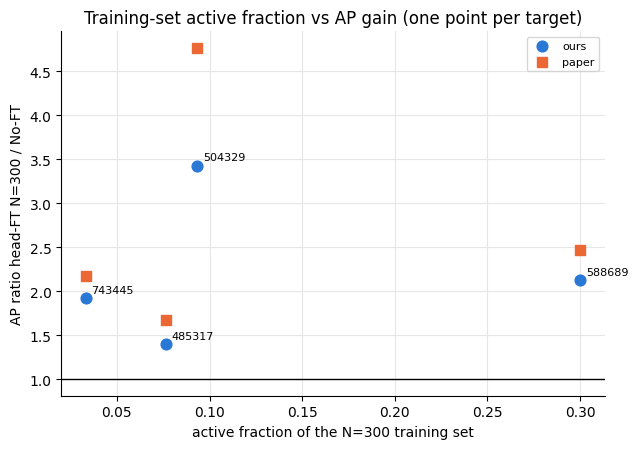

only 4 scored target(s): no correlation computed (needs at least 5 targets).


In [8]:
if len(APT):
    s = APT[APT.N == 300].merge(COMP[COMP.N == 300][["target", "active_frac"]], on="target")
    fig, ax = plt.subplots(figsize=(6.5, 4.6)); ax.scatter(s.active_frac, s.ours_ratio, s=60, color=OUR, label="ours")
    ax.scatter(s.active_frac, s.paper_ratio, s=60, color=THEIR, marker="s", label="paper")
    for _, r in s.iterrows(): ax.annotate(r.target, (r.active_frac, r.ours_ratio), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.axhline(1, color="black", lw=1); ax.set_xlabel("active fraction of the N=300 training set"); ax.set_ylabel("AP ratio head-FT N=300 / No-FT"); ax.set_title("Training-set active fraction vs AP gain (one point per target)"); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    if len(s) >= 5:
        rho, p = stats.spearmanr(s.active_frac, s.ours_ratio); print(f"Spearman rho = {rho:.2f}, p = {p:.3f}, n = {len(s)} targets")
    else: print(f"only {len(s)} scored target(s): no correlation computed (needs at least 5 targets).")
else: print("no fully scored target yet")

## 5. Training curves (validation loss per epoch)
From the per-epoch validation predictions of the head-FT runs. The validation set is the last 20 compounds of the No-FT ranking (paper protocol); `n_pos` below says how many are actually active. If all are inactive, the curve measures how well the head learns to lower the score of ranked-but-inactive compounds, not active/inactive separation.

pending: 2097 - no headft_full validation predictions yet
pending: 493091 - no headft_full validation predictions yet
pending: 2650 - no headft_full validation predictions yet
pending: 588549 - no headft_full validation predictions yet


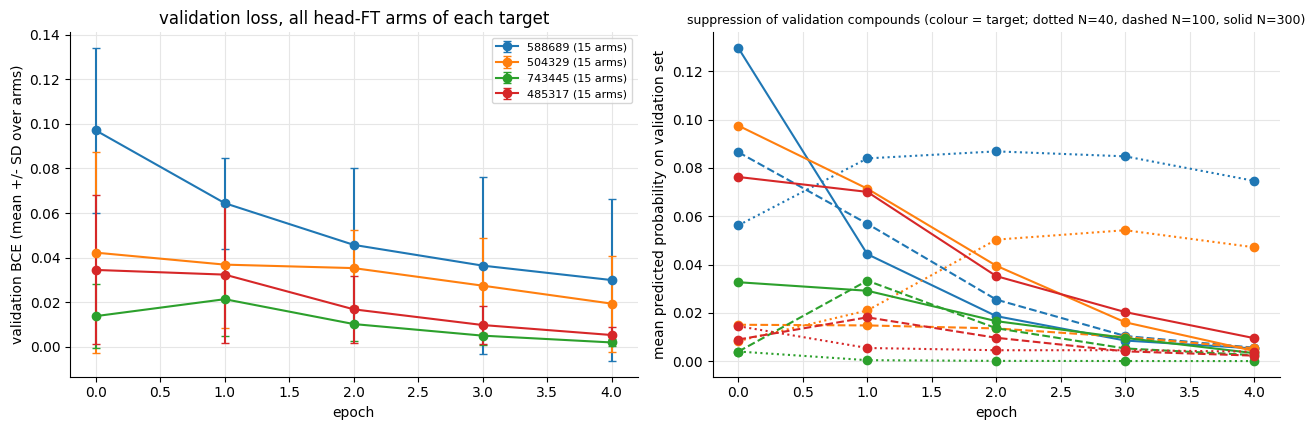

588689: validation set 20 compounds, 0 active; final-epoch BCE mean 0.030, epoch-0 0.097
504329: validation set 20 compounds, 0 active; final-epoch BCE mean 0.019, epoch-0 0.042
743445: validation set 20 compounds, 0 active; final-epoch BCE mean 0.002, epoch-0 0.014
485317: validation set 20 compounds, 0 active; final-epoch BCE mean 0.005, epoch-0 0.034


In [9]:
VC = {t: val_curves(t) for t in TARGETS}; T_VC = [t for t in TARGETS if VC[t] is not None]
for t in TARGETS:
    if VC[t] is None: print(f"pending: {SHORT[t]} - no headft_full validation predictions yet")
if T_VC:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4)); cm = plt.get_cmap("tab10")
    for i, t in enumerate(T_VC):
        v = VC[t]; g = v.groupby("epoch").val_bce.agg(["mean", "std"]); axes[0].errorbar(g.index, g["mean"], yerr=g["std"].fillna(0), marker="o", capsize=3, color=cm(i), label=f"{SHORT[t]} ({v.seed.nunique()*v.N.nunique()} arms)")
        for N in BUDGETS:
            s = v[v.N == N].groupby("epoch").val_prob.mean()
            if i == 0 or True: axes[1].plot(s.index, s.values, marker="o", color=cm(i), ls={40: ":", 100: "--", 300: "-"}[N], label=f"{SHORT[t]} N={N}" if len(T_VC) == 1 else None)
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation BCE (mean +/- SD over arms)"); axes[0].set_title("validation loss, all head-FT arms of each target"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("mean predicted probability on validation set"); axes[1].set_title("suppression of validation compounds (colour = target; dotted N=40, dashed N=100, solid N=300)")
    axes[1].title.set_fontsize(9)
    plt.tight_layout(); plt.show()
    for t in T_VC: print(f"{SHORT[t]}: validation set {int(VC[t].n.iloc[0])} compounds, {int(VC[t].n_pos.iloc[0])} active; final-epoch BCE mean {VC[t][VC[t].epoch==4].val_bce.mean():.3f}, epoch-0 {VC[t][VC[t].epoch==0].val_bce.mean():.3f}")

# Part II. Strategy variants (balanced, hard negatives, budgets)

Recipes from `prepare_train_variants.py`: `top` (top-N by score, the paper default), `balanced` (top-scored actives, N/2, plus random inactives), `hardneg` (all actives plus the top-scored inactives), `actdiv` (scaffold-diverse actives plus random inactives), `random`, `diverse`, `stratified`. All are scored on a held-out set, the compounds ranked below 1000 by No-FT, so that no arm is evaluated on its own selection pool. That set is smaller and harder than the standard evaluation set, so absolute AP here is not comparable with Part I (for example top-300 AP is lower here). Seed mean and SD over 5 seeds.

In [10]:
for t in TARGETS:
    if VAR[t] is None: print(f"{SHORT[t]}: no variant arms for this target yet")
    else:
        per, sp = VAR[t]; print(f"{SHORT[t]}: {len(per)} completed arms in {len(sp)} conditions; seeds per condition min/max = {sp.n_seeds.min()}/{sp.n_seeds.max()}; eval set {int(per.n_eval.iloc[0])} compounds, {int(per.n_active.iloc[0])} active")
CMP = {}
for t in T_VAR:
    per, sp = VAR[t]; CMP[t] = compare(per, "ap")
    # consistency with eval_variants.py output
    f = AN / t / "variants_compare.csv"
    if f.exists():
        c0 = pd.read_csv(f); c0 = c0[c0.metric == "AP"].merge(CMP[t], on=["n_train", "strategy"])
        print(f"  {SHORT[t]}: recomputed AP ratios/p-values vs variants_compare.csv, max abs diff ratio {np.abs(c0.ratio_vs_top - c0.ratio).max():.2e}, p {np.abs(c0.paired_p - c0.p).max():.2e} (n={len(c0)})")

588689: 70 completed arms in 14 conditions; seeds per condition min/max = 5/5; eval set 48985 compounds, 302 active
504329: no variant arms for this target yet
743445: no variant arms for this target yet
485317: no variant arms for this target yet
2097: no variant arms for this target yet
493091: no variant arms for this target yet
2650: no variant arms for this target yet
588549: no variant arms for this target yet
  588689: recomputed AP ratios/p-values vs variants_compare.csv, max abs diff ratio 3.33e-16, p 1.67e-15 (n=9)


## 6. Budget: does more top-N data keep helping?

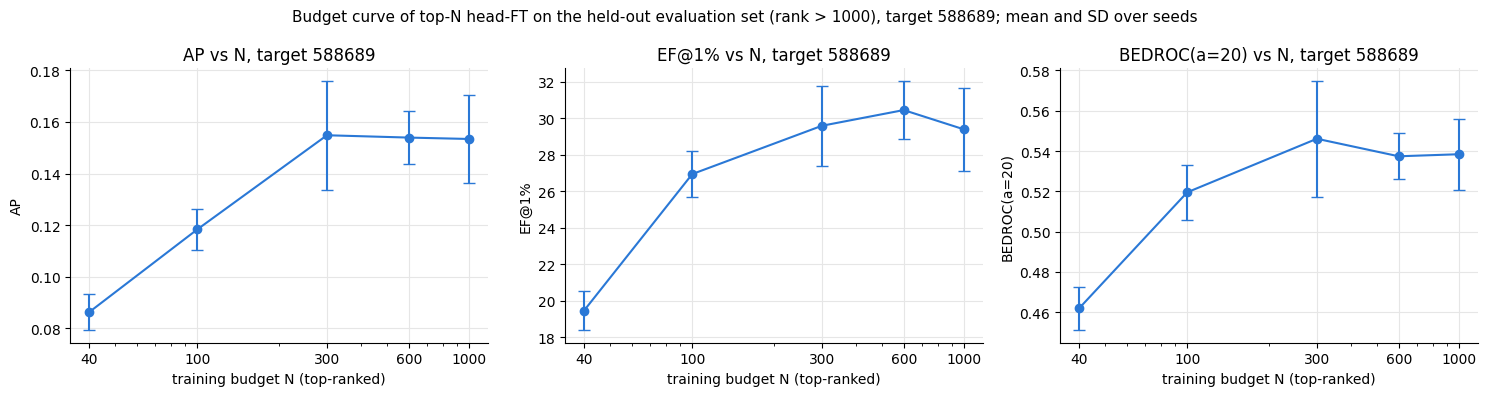

,n_train,n_seeds,ap_mean,ap_sd,ef1_mean,ef1_sd,bedroc_mean
0,40,5,0.0862,0.0070,19.4642,1.0828,0.4619
1,100,5,0.1183,0.0081,26.9454,1.2518,0.5195
8,300,5,0.1549,0.0211,29.5936,2.2032,0.5461
12,600,5,0.1540,0.0102,30.4543,1.6047,0.5374
13,1000,5,0.1534,0.0171,29.3950,2.2621,0.5384


,N,vs_N,ratio_geo,paired_p,n_seeds
0,40,300,0.560,0.001,5
1,100,300,0.768,0.032,5
2,600,300,1.000,0.999,5
3,1000,300,0.993,0.936,5


In [11]:
if not T_VAR: print("no variant arms for any target yet")
for t in T_VAR:
    per, sp = VAR[t]; s = sp[sp.strategy == "top"].sort_values("n_train")
    if len(s) < 2: print(f"{SHORT[t]}: fewer than 2 top-N budgets complete"); continue
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (k, nm) in zip(axes, [("ap", "AP"), ("ef1", "EF@1%"), ("bedroc", "BEDROC(a=20)")]):
        ax.errorbar(s.n_train, s[f"{k}_mean"], yerr=s[f"{k}_sd"], marker="o", color=OUR, capsize=4); ax.set_xscale("log"); ax.set_xticks(s.n_train); ax.set_xticklabels(s.n_train.astype(int))
        ax.set_xlabel("training budget N (top-ranked)"); ax.set_ylabel(nm); ax.set_title(f"{nm} vs N, target {SHORT[t]}")
    fig.suptitle(f"Budget curve of top-N head-FT on the held-out evaluation set (rank > 1000), target {SHORT[t]}; mean and SD over seeds", fontsize=11); plt.tight_layout(); plt.show()
    display(s[["n_train", "n_seeds", "ap_mean", "ap_sd", "ef1_mean", "ef1_sd", "bedroc_mean"]].round(4))
    # paired comparison of each larger budget against N=300
    tp = per[per.strategy == "top"].pivot(index="seed", columns="n_train", values="ap"); rows = []
    for N in [n for n in tp.columns if n != 300 and 300 in tp.columns]:
        a = tp[[N, 300]].dropna()
        if len(a) >= 2: rows.append(dict(N=N, vs_N=300, ratio_geo=float(np.exp(np.mean(np.log(a[N] / a[300])))), paired_p=float(stats.ttest_rel(np.log(a[N]), np.log(a[300])).pvalue), n_seeds=len(a)))
    BUD = pd.DataFrame(rows); display(BUD.round(3))

## 7. Composition at a fixed budget, and strategy versus top-N
Bars: seed-mean AP by strategy with SD, dashed line = top-N at that budget. Then the ratio to top-N (seed geometric mean of paired ratios) with a paired t-test over seeds on the log AP (the statistic of `eval_variants.py`). Here the seeds are the replicates, so inference is about seed-to-seed training noise on one target, not about new targets.

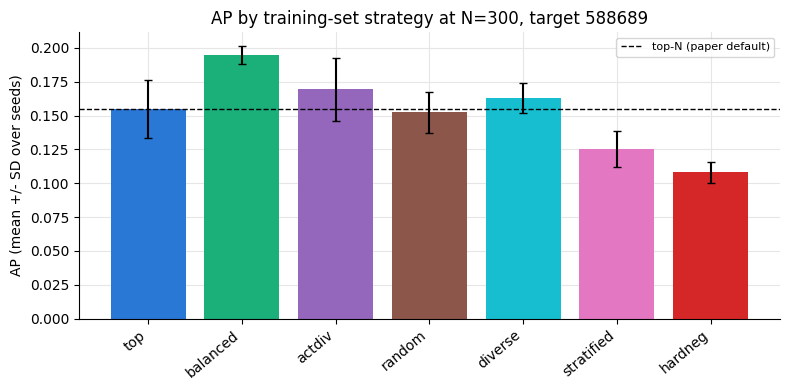

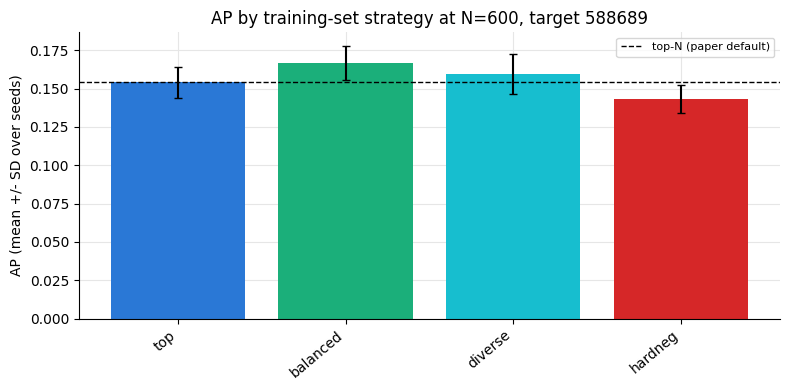

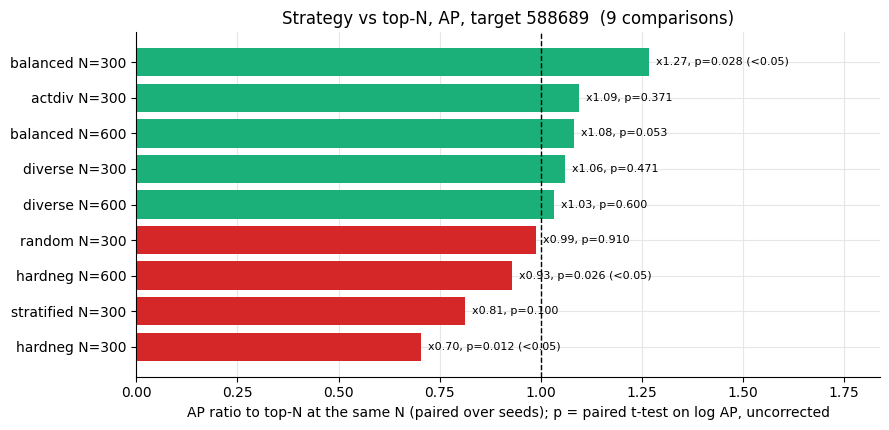

,n_train,strategy,top_mean,strat_mean,ratio,n_seeds,p,below_0.05,below_Bonferroni_0.0056
0,300,actdiv,0.1549,0.1695,1.0941,5,0.3709,False,False
1,300,balanced,0.1549,0.1950,1.2678,5,0.0280,True,False
2,300,diverse,0.1549,0.1634,1.0610,5,0.4711,False,False
3,300,hardneg,0.1549,0.1082,0.7027,5,0.0119,True,False
4,300,random,0.1549,0.1525,0.9879,5,0.9104,False,False
5,300,stratified,0.1549,0.1256,0.8132,5,0.0999,False,False
6,600,balanced,0.1540,0.1665,1.0816,5,0.0527,False,False
7,600,diverse,0.1540,0.1593,1.0337,5,0.5998,False,False
8,600,hardneg,0.1540,0.1429,0.9285,5,0.0263,True,False


target 588689: 9 AP strategy-vs-top comparisons, Bonferroni threshold 0.05/9 = 0.0056; 3 have uncorrected p < 0.05 and 0 pass Bonferroni.


In [12]:
for t in T_VAR:
    per, sp = VAR[t]; c = CMP[t]
    for N in sorted(sp.n_train.unique()):
        s = sp[sp.n_train == N].copy()
        if len(s) < 2 or N not in (300, 600): continue
        s["o"] = s.strategy.map({k: i for i, k in enumerate(VAR_STRATS)}); s = s.sort_values("o")
        fig, ax = plt.subplots(figsize=(8, 4)); ax.bar(range(len(s)), s.ap_mean, yerr=s.ap_sd, capsize=3, color=[COL[k] for k in s.strategy])
        ax.axhline(s[s.strategy == "top"].ap_mean.iloc[0], color="black", ls="--", lw=1, label="top-N (paper default)")
        ax.set_xticks(range(len(s))); ax.set_xticklabels(s.strategy, rotation=40, ha="right"); ax.set_ylabel("AP (mean +/- SD over seeds)"); ax.legend(fontsize=8)
        ax.set_title(f"AP by training-set strategy at N={N}, target {SHORT[t]}"); plt.tight_layout(); plt.show()
    m = len(c); thr = 0.05 / m if m else np.nan
    cc = c.sort_values("ratio").copy(); cc["label"] = cc.strategy + " N=" + cc.n_train.astype(str)
    fig, ax = plt.subplots(figsize=(9, 0.8 + 0.4 * len(cc)))
    ax.barh(cc.label, cc.ratio, color=["#1baf7a" if r > 1 else "#d62728" for r in cc.ratio]); ax.axvline(1, color="black", ls="--", lw=1)
    for y, (r, p) in enumerate(zip(cc.ratio, cc.p)): ax.text(r, y, f"  x{r:.2f}, p={p:.3f}" + (" (<0.05)" if p < 0.05 else ""), va="center", fontsize=8)
    ax.set_xlabel("AP ratio to top-N at the same N (paired over seeds); p = paired t-test on log AP, uncorrected"); ax.set_title(f"Strategy vs top-N, AP, target {SHORT[t]}  ({m} comparisons)")
    ax.set_xlim(0, cc.ratio.max() * 1.45); plt.tight_layout(); plt.show()
    c2 = c.copy(); c2["below_0.05"] = c2.p < 0.05; c2[f"below_Bonferroni_{thr:.4f}"] = c2.p < thr; display(c2.round(4))
    print(f"target {SHORT[t]}: {m} AP strategy-vs-top comparisons, Bonferroni threshold 0.05/{m} = {thr:.4f}; {int((c.p < 0.05).sum())} have uncorrected p < 0.05 and {int((c.p < thr).sum())} pass Bonferroni.")
if not T_VAR: print("no variant arms for any target yet")

## 8. Why: positives supplied and negative hardness
For each strategy's N=300 training set: number of actives and the mean No-FT score of the training inactives (higher means harder, more decoy-like). Then eval AP against the number of training actives (if more positives were all that mattered it would rise monotonically), and the two controlled contrasts. Lever A: `balanced` vs `actdiv` (same number of actives and random inactives; top-scored vs scaffold-diverse actives). Lever B: `balanced` vs `hardneg` (easy vs hard inactives). Paired over seeds on raw AP, with paired t-test and Wilcoxon, as in the original notebook.

,n_train,n_act,act_frac,inactive_mean_noft_score,ap_mean,ap_sd
strategy,,,,,,
top,300,90,0.300,0.658,0.155,0.021
balanced,300,150,0.500,0.607,0.195,0.007
actdiv,300,150,0.500,0.607,0.169,0.023
random,300,58,0.193,0.606,0.152,0.015
diverse,300,76,0.253,0.653,0.163,0.011
stratified,300,62,0.207,0.607,0.126,0.013
hardneg,300,184,0.613,0.674,0.108,0.008


,lever,first,second,first_ap,second_ap,diff,t_p,wilcoxon_p,first_higher
0,A: which actives,balanced,actdiv,0.195,0.1695,0.0255,0.0435,0.0625,5/5 seeds
1,B: which inactives,balanced,hardneg,0.195,0.1082,0.0867,0.0000,0.0625,5/5 seeds


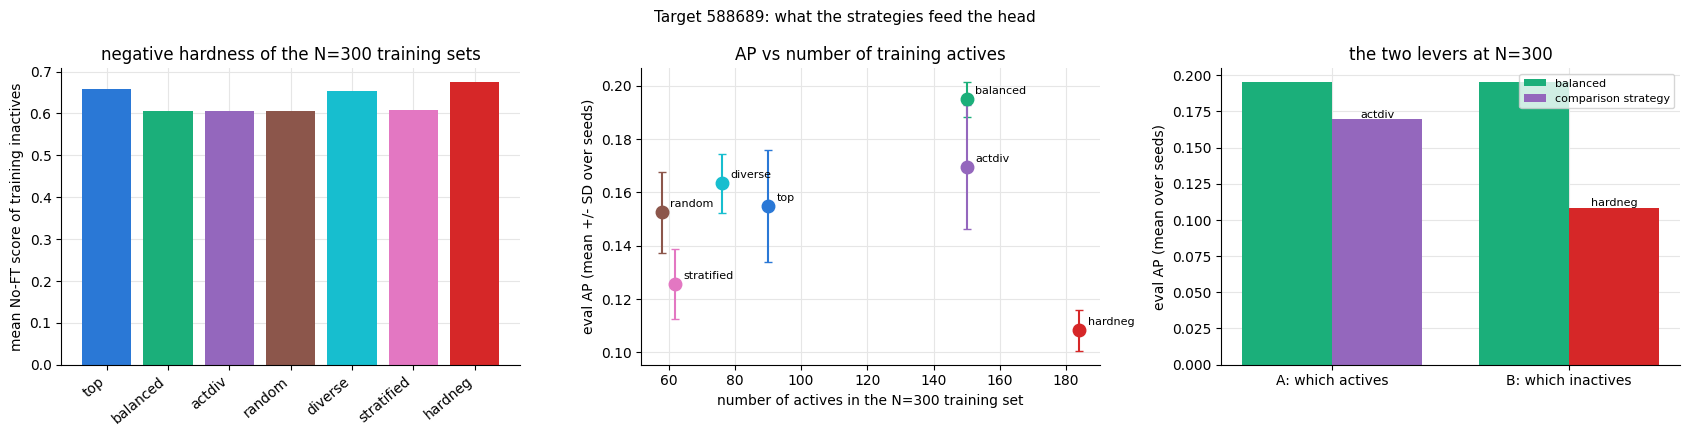

In [13]:
LEV = {}
for t in T_VAR:
    per, sp = VAR[t]; m = var_ml(t)
    if m is None: print(f"{SHORT[t]}: ft_inputs_variants/ml_table.csv missing"); continue
    lab = m.is_binder.astype(int); noft = m.affinity_probability_binary; rows = []
    for s in VAR_STRATS:
        ids = var_train_ids(t, s, 300)
        if ids is None: continue
        a = [i for i in ids if lab.get(i, 0) == 1]; ina = [i for i in ids if lab.get(i, 0) == 0]; r = sp[(sp.strategy == s) & (sp.n_train == 300)]
        rows.append(dict(strategy=s, n_train=len(ids), n_act=len(a), act_frac=len(a) / len(ids), inactive_mean_noft_score=float(noft.reindex(ina).mean()) if ina else np.nan,
                         ap_mean=r.ap_mean.iloc[0] if len(r) else np.nan, ap_sd=r.ap_sd.iloc[0] if len(r) else np.nan))
    comp = pd.DataFrame(rows).set_index("strategy"); display(comp.round(3)); LEV[t] = comp
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.4)); xs = np.arange(len(comp)); cols = [COL[k] for k in comp.index]
    axes[0].bar(xs, comp.inactive_mean_noft_score, color=cols); axes[0].set_xticks(xs); axes[0].set_xticklabels(comp.index, rotation=40, ha="right"); axes[0].set_ylabel("mean No-FT score of training inactives"); axes[0].set_title("negative hardness of the N=300 training sets")
    for k in comp.index:
        r = comp.loc[k]; axes[1].errorbar(r.n_act, r.ap_mean, yerr=r.ap_sd, marker="o", ms=9, color=COL[k], capsize=3); axes[1].annotate(k, (r.n_act, r.ap_mean), xytext=(6, 4), textcoords="offset points", fontsize=8)
    axes[1].set_xlabel("number of actives in the N=300 training set"); axes[1].set_ylabel("eval AP (mean +/- SD over seeds)"); axes[1].set_title("AP vs number of training actives")
    ps = per[per.n_train == 300]; lines = []
    for ax, (x1, x2, nm) in zip([axes[2]], [("balanced", "actdiv", "")]): pass
    pairs = [("A: which actives", "balanced", "actdiv"), ("B: which inactives", "balanced", "hardneg")]; res = []
    for lab_, s1, s2 in pairs:
        a = ps[ps.strategy == s1].set_index("seed").ap.sort_index(); b = ps[ps.strategy == s2].set_index("seed").ap.sort_index(); sd = sorted(set(a.index) & set(b.index))
        if len(sd) < 2: continue
        a, b = a.loc[sd], b.loc[sd]
        try: w = stats.wilcoxon(a, b).pvalue
        except Exception: w = np.nan
        res.append(dict(lever=lab_, first=s1, second=s2, first_ap=a.mean(), second_ap=b.mean(), diff=a.mean() - b.mean(), t_p=stats.ttest_rel(a, b).pvalue, wilcoxon_p=w, first_higher=f"{int((a > b).sum())}/{len(sd)} seeds"))
    R = pd.DataFrame(res); LEV[t] = (comp, R)
    if len(R):
        xs2 = np.arange(len(R)); w = 0.38
        axes[2].bar(xs2 - w / 2, R.first_ap, w, color=COL["balanced"], label="balanced"); axes[2].bar(xs2 + w / 2, R.second_ap, w, color=[COL[s] for s in R.second], label="comparison strategy")
        for i, r in R.iterrows(): axes[2].text(i + w / 2, r.second_ap, r.second, ha="center", va="bottom", fontsize=8)
        axes[2].set_xticks(xs2); axes[2].set_xticklabels(R.lever); axes[2].set_ylabel("eval AP (mean over seeds)"); axes[2].set_title("the two levers at N=300"); axes[2].legend(fontsize=8)
        display(R.round(4))
    fig.suptitle(f"Target {SHORT[t]}: what the strategies feed the head", fontsize=11); plt.tight_layout(); plt.show()
if not T_VAR: print("no variant arms for any target yet")

## 9. Recovery in the top 1% and the hard-negative failure (seed 0)
Actives among the top 1% of the held-out ranking for each N=300 strategy (seed 0 only, a single run each, so read as illustration). For `hardneg`, the share of true actives that it scores below what `top` gives them.

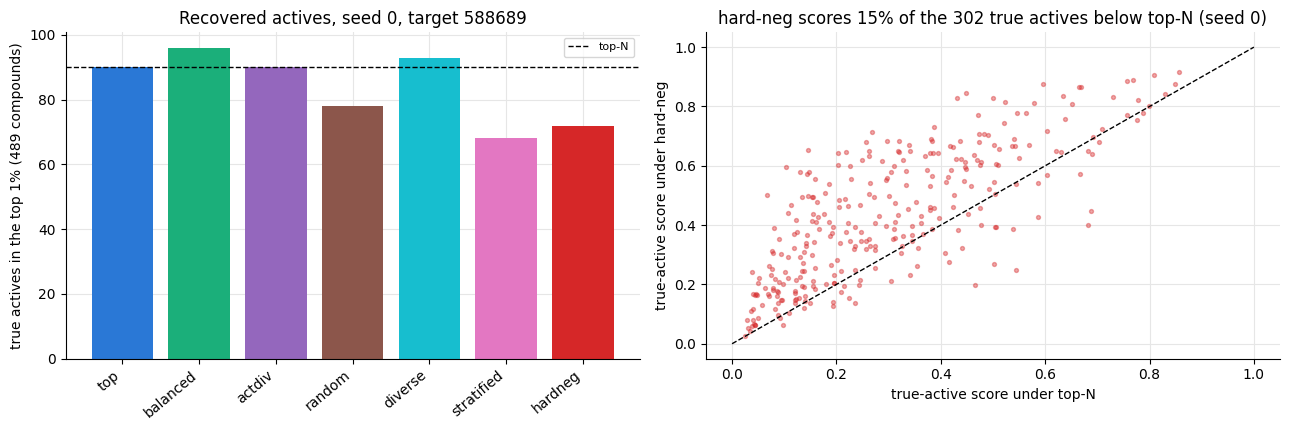

588689 top-1% actives, seed 0: balanced only 21, both 75, top-N only 15


In [14]:
for t in T_VAR:
    m = var_ml(t); ev = var_eval_ids(t)
    if m is None or ev is None: continue
    lab = m.is_binder.astype(int); y = lab.reindex(ev).fillna(0).astype(int).values; k = max(1, int(0.01 * len(ev)))
    SC = {s: var_arm_scores(t, f"{s}_N300") for s in VAR_STRATS}; SC = {s: v for s, v in SC.items() if v is not None and v.notna().all()}
    if "top" not in SC: print(f"{SHORT[t]}: no seed-0 top_N300 scores"); continue
    rec = {s: int(lab.reindex(v.nlargest(k).index).sum()) for s, v in SC.items()}
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4)); axes[0].bar(range(len(rec)), list(rec.values()), color=[COL[s] for s in rec]); axes[0].axhline(rec["top"], color="black", ls="--", lw=1, label="top-N")
    axes[0].set_xticks(range(len(rec))); axes[0].set_xticklabels(list(rec), rotation=40, ha="right"); axes[0].set_ylabel(f"true actives in the top 1% ({k} compounds)"); axes[0].set_title(f"Recovered actives, seed 0, target {SHORT[t]}"); axes[0].legend(fontsize=8)
    if "hardneg" in SC:
        a = y == 1; hn = SC["hardneg"].values[a]; tp = SC["top"].values[a]; dem = float(np.mean(hn < tp))
        axes[1].scatter(tp, hn, s=8, alpha=0.4, color=COL["hardneg"]); axes[1].plot([0, 1], [0, 1], "k--", lw=1); axes[1].set_xlabel("true-active score under top-N"); axes[1].set_ylabel("true-active score under hard-neg")
        axes[1].set_title(f"hard-neg scores {100*dem:.0f}% of the {int(a.sum())} true actives below top-N (seed 0)")
    plt.tight_layout(); plt.show()
    if "balanced" in SC:
        ba = set(i for i in SC["balanced"].nlargest(k).index if lab.get(i, 0) == 1); to = set(i for i in SC["top"].nlargest(k).index if lab.get(i, 0) == 1)
        print(f"{SHORT[t]} top-1% actives, seed 0: balanced only {len(ba - to)}, both {len(ba & to)}, top-N only {len(to - ba)}")
if not T_VAR: print("no variant arms for any target yet")

## Conclusions (computed from the data above)

In [15]:
from IPython.display import Markdown
L = []
L.append("### Part I, standard top-N selection")
L.append(f"- Targets with training sets: {[SHORT[t] for t in T_SET]}; fully scored: {[SHORT[t] for t in T_AP]}; pending scoring: {[SHORT[t] for t in T_SET if t not in T_AP]}; no inputs yet: {[SHORT[t] for t in TARGETS if t not in T_SET]}.")
if len(COMP):
    for t in T_SET:
        c = COMP[COMP.target == SHORT[t]].set_index("N")
        L.append(f"- {SHORT[t]}: training actives {int(c.loc[40,'n_active'])}/40, {int(c.loc[100,'n_active'])}/100, {int(c.loc[300,'n_active'])}/300 (library rate {c.pool_rate.iloc[0]:.2%}, top-300 enrichment x{c.loc[300,'enrichment']:.0f}). The selection file is single per N, so all seeds share the training set.")
if len(APT):
    for t in T_AP:
        s = APT[APT.target == SHORT[t]].set_index("N")
        L.append(f"- {SHORT[t]}: No-FT AP {s.ours_noft.iloc[0]:.3f} (paper {s.paper_noft.iloc[0]:.3f}); head-FT AP (ours mean +/- SD, paper single seed; ratio to No-FT) N=40 {s.loc[40,'ours_ap']:.3f} +/- {s.loc[40,'ours_sd']:.3f} ({s.loc[40,'paper_ap']:.3f}; x{s.loc[40,'ours_ratio']:.2f}), "
                 f"N=100 {s.loc[100,'ours_ap']:.3f} +/- {s.loc[100,'ours_sd']:.3f} ({s.loc[100,'paper_ap']:.3f}; x{s.loc[100,'ours_ratio']:.2f}), N=300 {s.loc[300,'ours_ap']:.3f} +/- {s.loc[300,'ours_sd']:.3f} ({s.loc[300,'paper_ap']:.3f}; x{s.loc[300,'ours_ratio']:.2f}).")
    if len(XT) and XT.n_targets.min() < 3: L.append(f"- Only {int(XT.n_targets.max())} fully scored target(s): no cross-target interval is computed, so nothing here supports a cross-target claim about the effect of N yet.")
    elif len(XT): L.append("- Cross-target geometric-mean AP ratios (95% t interval over targets): " + "; ".join(f"N={int(r.N)} x{r.ours_geo_ratio:.2f} {r.ours_95CI} (paper, same targets x{r.paper_geo_ratio_same_targets:.2f})" for r in XT.itertuples()) + ".")
L.append("")
L.append("### Part II, strategy variants")
L.append(f"- Targets with variant arms: {[SHORT[t] for t in T_VAR]}. Without variant arms: {[SHORT[t] for t in TARGETS if t not in T_VAR]}. Whether balanced selection helps or hard negatives hurt on any other target is therefore untested; it will be filled in when those targets have variant arms.")
for t in T_VAR:
    per, sp = VAR[t]; c = CMP[t]; m = len(c); thr = 0.05 / m if m else np.nan; top = sp[sp.strategy == "top"].sort_values("n_train")
    L.append(f"- {SHORT[t]} budget (top-N AP on the held-out set): " + ", ".join(f"N={int(r.n_train)} {r.ap_mean:.3f}" for r in top.itertuples()) + ". " +
             ("Against N=300 (paired over seeds): " + "; ".join(f"N={int(r.N)} x{r.ratio_geo:.2f} (p={r.paired_p:.2f})" for r in BUD.itertuples()) + ". " if len(BUD) else "") +
             "No significant gain beyond N=300 means none detected with 5 seeds, not proof of saturation.")
    def g(s, n):
        r = c[(c.strategy == s) & (c.n_train == n)]; return None if not len(r) else r.iloc[0]
    parts = []
    for s, n in [("balanced", 300), ("hardneg", 300), ("actdiv", 300), ("diverse", 300), ("random", 300), ("stratified", 300), ("balanced", 600), ("hardneg", 600), ("diverse", 600)]:
        r = g(s, n)
        if r is not None: parts.append(f"{s} N={n} x{r.ratio:.2f} (p={r.p:.3f})")
    L.append(f"- {SHORT[t]} AP ratio to top-N, paired p: " + "; ".join(parts) + ".")
    L.append(f"- Multiple comparisons: {m} strategy-vs-top comparisons, Bonferroni threshold {thr:.4f}; {int((c.p < 0.05).sum())} have p < 0.05 uncorrected and {int((c.p < thr).sum())} pass Bonferroni. Anything with p between {thr:.4f} and 0.05 is suggestive only.")
    if t in LEV and isinstance(LEV[t], tuple) and len(LEV[t][1]):
        for r in LEV[t][1].itertuples():
            L.append(f"- {SHORT[t]} lever {r.lever}: {r.first} {r.first_ap:.3f} vs {r.second} {r.second_ap:.3f}, {r.first_higher} higher, paired t p=" + (f"{r.t_p:.4f}" if r.t_p >= 1e-4 else "<0.0001") + f", Wilcoxon p={r.wilcoxon_p:.3f} (with 5 seeds the smallest possible two-sided Wilcoxon p is 0.0625)" + (" (only a single contrast, borderline)." if 0.01 < r.t_p < 0.1 else "."))
    L.append(f"- Scope: target {SHORT[t]} only, {int(per.seed.nunique())} seeds, held-out set of compounds ranked below 1000 (n={int(per.n_eval.iloc[0])}); the paired tests treat seeds as replicates, so they describe training noise on this target, not variation between targets.")
display(Markdown("\n".join(L)))

### Part I, standard top-N selection
- Targets with training sets: ['588689', '504329', '743445', '485317', '493091']; fully scored: ['588689', '504329', '743445', '485317']; pending scoring: ['493091']; no inputs yet: ['2097', '2650', '588549'].
- 588689: training actives 16/40, 32/100, 90/300 (library rate 0.97%, top-300 enrichment x31). The selection file is single per N, so all seeds share the training set.
- 504329: training actives 4/40, 11/100, 28/300 (library rate 0.93%, top-300 enrichment x10). The selection file is single per N, so all seeds share the training set.
- 743445: training actives 0/40, 5/100, 10/300 (library rate 0.29%, top-300 enrichment x12). The selection file is single per N, so all seeds share the training set.
- 485317: training actives 1/40, 9/100, 23/300 (library rate 1.95%, top-300 enrichment x4). The selection file is single per N, so all seeds share the training set.
- 493091: training actives 8/40, 16/100, 43/300 (library rate 1.56%, top-300 enrichment x9). The selection file is single per N, so all seeds share the training set.
- 588689: No-FT AP 0.097 (paper 0.096); head-FT AP (ours mean +/- SD, paper single seed; ratio to No-FT) N=40 0.125 +/- 0.006 (0.165; x1.28), N=100 0.155 +/- 0.008 (0.202; x1.60), N=300 0.207 +/- 0.015 (0.237; x2.12).
- 504329: No-FT AP 0.051 (paper 0.047); head-FT AP (ours mean +/- SD, paper single seed; ratio to No-FT) N=40 0.106 +/- 0.003 (0.111; x2.09), N=100 0.114 +/- 0.008 (0.139; x2.25), N=300 0.174 +/- 0.021 (0.222; x3.42).
- 743445: No-FT AP 0.022 (paper 0.022); head-FT AP (ours mean +/- SD, paper single seed; ratio to No-FT) N=40 0.045 +/- 0.001 (0.027; x2.01), N=100 0.036 +/- 0.003 (0.031; x1.62), N=300 0.043 +/- 0.002 (0.048; x1.92).
- 485317: No-FT AP 0.039 (paper 0.036); head-FT AP (ours mean +/- SD, paper single seed; ratio to No-FT) N=40 0.045 +/- 0.001 (0.040; x1.15), N=100 0.042 +/- 0.001 (0.041; x1.09), N=300 0.054 +/- 0.002 (0.060; x1.39).
- Cross-target geometric-mean AP ratios (95% t interval over targets): N=40 x1.58 [0.97, 2.57] (paper, same targets x1.53); N=100 x1.59 [0.99, 2.55] (paper, same targets x1.78); N=300 x2.10 [1.16, 3.80] (paper, same targets x2.55).

### Part II, strategy variants
- Targets with variant arms: ['588689']. Without variant arms: ['504329', '743445', '485317', '2097', '493091', '2650', '588549']. Whether balanced selection helps or hard negatives hurt on any other target is therefore untested; it will be filled in when those targets have variant arms.
- 588689 budget (top-N AP on the held-out set): N=40 0.086, N=100 0.118, N=300 0.155, N=600 0.154, N=1000 0.153. Against N=300 (paired over seeds): N=40 x0.56 (p=0.00); N=100 x0.77 (p=0.03); N=600 x1.00 (p=1.00); N=1000 x0.99 (p=0.94). No significant gain beyond N=300 means none detected with 5 seeds, not proof of saturation.
- 588689 AP ratio to top-N, paired p: balanced N=300 x1.27 (p=0.028); hardneg N=300 x0.70 (p=0.012); actdiv N=300 x1.09 (p=0.371); diverse N=300 x1.06 (p=0.471); random N=300 x0.99 (p=0.910); stratified N=300 x0.81 (p=0.100); balanced N=600 x1.08 (p=0.053); hardneg N=600 x0.93 (p=0.026); diverse N=600 x1.03 (p=0.600).
- Multiple comparisons: 9 strategy-vs-top comparisons, Bonferroni threshold 0.0056; 3 have p < 0.05 uncorrected and 0 pass Bonferroni. Anything with p between 0.0056 and 0.05 is suggestive only.
- 588689 lever A: which actives: balanced 0.195 vs actdiv 0.169, 5/5 seeds higher, paired t p=0.0435, Wilcoxon p=0.062 (with 5 seeds the smallest possible two-sided Wilcoxon p is 0.0625) (only a single contrast, borderline).
- 588689 lever B: which inactives: balanced 0.195 vs hardneg 0.108, 5/5 seeds higher, paired t p=<0.0001, Wilcoxon p=0.062 (with 5 seeds the smallest possible two-sided Wilcoxon p is 0.0625).
- Scope: target 588689 only, 5 seeds, held-out set of compounds ranked below 1000 (n=48985); the paired tests treat seeds as replicates, so they describe training noise on this target, not variation between targets.